# The bbox-tightening process, step by step -- `gray_inverted` vs. `hematoxylin_od`

Visual companion to `production_seed_precision_at_k_chromatin_hem_bbox.ipynb`. That notebook
measured precision@K; this one exists to *look at* what the Otsu bbox-tightening step
(`seed_selection.tighten_box_otsu`, wrapped by `tightened_template_box`) is actually doing to
each channel, and what the resulting template looks like.

**Scope.** One ROI per domain (7 domains -> 7 ROIs; the alphabetically-first file per domain,
e.g. `013.tiff` over `094.tiff` for human breast cancer -- a simple, stated rule, not a
significance claim), two mitotic annotations per ROI (drawn from the same
`agreement_pool` + `border_filter` candidate pool every notebook in this family draws from,
RNG-seeded `[0, image_id]` and `[1, image_id]` so the picks are reproducible. **Correction**
(an independent audit, `Research Logs/2026-09-16-tightening-process-hem-vs-gray-audit.md`,
Finding T2-3): an earlier version of this cell claimed the first pick was "literally the same
click `production_seed_precision_at_k_chromatin_hem_bbox.ipynb` used for that ROI at
`seed_index=0`." That is true of the *other* sibling instead -- the `gray_inverted`-tightened
`half_pix_fix` baseline matches `#1` on 7/7 ROIs, since it draws with no retry, same as here;
`hem_bbox.ipynb` retries on a refusal, so it only matches `#1` on 4/7 -- the three ROIs
(`300.tiff`, `245.tiff`, `013.tiff`) where `hematoxylin_od` refuses `#1` here and `hem_bbox`
redrew. 7 x 2 = 14 examples, each run under both channels.

**Every step**, per example per channel:
1. The raw Otsu-window patch (51px, `template_match.BASE_SIZE`) around the click, from that
   channel.
2. `cv2.normalize` to uint8, then `cv2.THRESH_BINARY + cv2.THRESH_OTSU` -- the binary foreground
   mask, with the Otsu cut value shown.
3. Connected components (`skimage.measure.label`, connectivity=2) -- which component (if any)
   contains the click, its area/solidity, and whether it passes the sanity gates
   (`min_area=50`, `max_area_frac=0.85`, `min_solidity=0.5` -- `tighten_box_otsu`'s defaults,
   the same ones every notebook in this family uses; `method="binary"`, `center_tolerance=0`).
4. The tightened bounding box and recentred template point, drawn in spatial context on the
   full-resolution RGB crop -- or, when the gate refuses, why.
5. The final template crop itself, at its actual size -- "what the template looks like."

Every accept/refuse decision, bounding box, `base_size` and template centre here is
cross-checked against the real `seed_selection.tighten_box_otsu`/`tightened_template_box` (not
just a visual approximation of them) -- see the assertion at the end of the run cell. (The
Otsu cut value, component label, area, solidity and refusal-reason string rendered into each
panel are not covered by that assertion -- `tighten_box_otsu` returns a bare `None` on refusal,
so the reason string is structurally uncheckable that way -- though an independent audit
verified all of these separately; Finding T3-4.)

In [1]:
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage.color import label2rgb

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

IMAGES_DIR = '../images/extra_valid'
DB_PATH = '../databases/MIDOG++.json'

OTSU_WINDOW = tm.BASE_SIZE          # 51 -- same window tighten_box_otsu reads everywhere else
MIN_AREA, MAX_AREA_FRAC, MIN_SOLIDITY = 50, 0.85, 0.5   # tighten_box_otsu's own defaults
BORDER = fs.FSConfig().patch_size // 2   # 36 -- same margin border_filter uses elsewhere

CHANNELS = {
    'gray_inverted (current production)': 'gray_inverted',
    'hematoxylin_od (candidate)': 'hematoxylin_od',
}

CONTEXT_WINDOW = 91                 # display-only crop size for the spatial-context panel

print(f'OTSU_WINDOW={OTSU_WINDOW}px, gates: area>={MIN_AREA}px, area<={MAX_AREA_FRAC:.0%} of '
      f'window, solidity>={MIN_SOLIDITY}')

OTSU_WINDOW=51px, gates: area>=50px, area<=85% of window, solidity>=0.5


## `explore_tightening` -- the same steps `tighten_box_otsu` runs, with every intermediate kept

Mirrors `seed_selection.py:89-154` line for line (see the docstring there) so the plots below are
faithful to the real function, not an approximation of it. The run cell cross-checks every result
against calling `ss.tighten_box_otsu`/`ss.tightened_template_box` directly.

In [2]:
def explore_tightening(channel_img, cx, cy, otsu_window=OTSU_WINDOW, min_area=MIN_AREA,
                       max_area_frac=MAX_AREA_FRAC, min_solidity=MIN_SOLIDITY):
    '''Reimplements tighten_box_otsu's internals (method="binary", center_tolerance=0), keeping
    every intermediate array for plotting. Returns a dict; see the keys set below.'''
    patch = tm.read_padded_patch(channel_img, cx, cy, otsu_window)
    result = dict(patch=patch, u8=None, binary=None, otsu_thresh=None, labels=None,
                  center_label=0, region=None, accepted=False,
                  reason='too close to the ROI border to read the Otsu window',
                  bbox=None, base_size=None, center_xy=None)
    if patch is None:
        return result

    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    otsu_thresh, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels = label(binary, connectivity=2)
    result.update(u8=u8, binary=binary, otsu_thresh=float(otsu_thresh), labels=labels)

    py, px = patch.shape[0] // 2, patch.shape[1] // 2
    center_label = int(labels[py, px])
    result['center_label'] = center_label
    if center_label == 0:
        result['reason'] = 'click lands on background at this Otsu cut'
        return result

    region = next(r for r in regionprops(labels) if r.label == center_label)
    result['region'] = region
    min_row, min_col, max_row, max_col = region.bbox
    if not (min_row <= py < max_row and min_col <= px < max_col):
        result['reason'] = "accepted component's bbox does not actually contain the click pixel"
        return result
    if region.area < min_area:
        result['reason'] = f'component area {region.area}px < min_area {min_area}px'
        return result
    if region.area > max_area_frac * patch.size:
        result['reason'] = (f'component area {region.area}px > {max_area_frac:.0%} of the '
                            f'{patch.size}px window')
        return result
    if region.solidity < min_solidity:
        result['reason'] = f'component solidity {region.solidity:.2f} < min_solidity {min_solidity}'
        return result

    y0, x0, y1, x1 = region.bbox  # skimage bbox order is (min_row, min_col, max_row, max_col)
    base_size = ss._odd(max(y1 - y0, x1 - x0), minimum=5)
    half = otsu_window // 2
    ix, iy = int(round(cx)), int(round(cy))
    center_x = ix - half + (x0 + x1 - 1) / 2.0
    center_y = iy - half + (y0 + y1 - 1) / 2.0
    result.update(accepted=True, reason='accepted', bbox=(int(y0), int(y1), int(x0), int(x1)),
                  base_size=int(base_size), center_xy=(center_x, center_y))
    return result


def plot_channel_row(axes, ch_label, res, rgb, cx, cy):
    ax_patch, ax_mask, ax_labels, ax_context, ax_template = axes
    # row label, independent of any panel's own title -- readable even scanning column 5
    ax_patch.text(-0.18, 0.5, ch_label, transform=ax_patch.transAxes, rotation=90,
                  va='center', ha='center', fontsize=10, fontweight='bold')

    if res['patch'] is None:
        ax_patch.text(0.5, 0.5, res['reason'], ha='center', va='center', wrap=True, fontsize=9)
        for a in axes:
            a.axis('off')
        return

    py = px = res['patch'].shape[0] // 2

    ax_patch.imshow(res['patch'], cmap='gray')
    ax_patch.plot(px, py, marker='+', color='red', ms=13, mew=2)
    ax_patch.set_title(f"raw patch ({res['patch'].shape[0]}px)", fontsize=9)

    ax_mask.imshow(res['binary'], cmap='gray')
    ax_mask.plot(px, py, marker='+', color='red', ms=13, mew=2)
    ax_mask.set_title(f"Otsu binary (cut={res['otsu_thresh']:.1f}/255)", fontsize=9)

    # label2rgb (not a continuous colormap) so a handful of components get visibly distinct
    # colors instead of near-identical dark shades; the accepted component is also outlined.
    ax_labels.imshow(label2rgb(res['labels'], bg_label=0))
    ax_labels.plot(px, py, marker='+', color='white', ms=13, mew=2, mec='white')
    if res['center_label'] != 0:
        ax_labels.contour(res['labels'] == res['center_label'], levels=[0.5], colors='lime',
                          linewidths=2)
    if res['region'] is not None:
        r = res['region']
        verdict = 'ACCEPTED' if res['accepted'] else f"REFUSED: {res['reason']}"
        ax_labels.set_title(f"components (label={res['center_label']})\n"
                            f"area={int(r.area)}px solidity={r.solidity:.2f}\n{verdict}", fontsize=8)
    else:
        ax_labels.set_title(f"components\nREFUSED: {res['reason']}", fontsize=8)

    # Context crop, positioned in a fixed nominal-window coordinate frame (not the crop's own
    # array indices): near a ROI edge the crop itself gets clamped, and separately the tightened
    # bbox can extend past CONTEXT_WINDOW on a large/recentred template -- both would silently
    # mislead if drawn in raw array-local coordinates, since axis('off') hides anything that
    # renders outside the visible crop. Fixed xlim/ylim on the nominal frame instead make either
    # case visibly what it is (a clamped crop, or a bbox that doesn't fully fit) rather than
    # invisible or mispositioned.
    half_ctx = CONTEXT_WINDOW // 2
    ix, iy = int(round(cx)), int(round(cy))
    h, w = rgb.shape[:2]
    x0n, x1n = ix - half_ctx, ix + half_ctx + 1
    y0n, y1n = iy - half_ctx, iy + half_ctx + 1
    x0c, x1c = max(0, x0n), min(w, x1n)
    y0c, y1c = max(0, y0n), min(h, y1n)
    crop = rgb[y0c:y1c, x0c:x1c]
    ax_context.imshow(crop, extent=(x0c - x0n, x1c - x0n, y1c - y0n, y0c - y0n))
    ax_context.set_xlim(0, x1n - x0n)
    ax_context.set_ylim(y1n - y0n, 0)
    click_local = (ix - x0n, iy - y0n)
    ax_context.plot(*click_local, marker='x', color='red', ms=11, mew=2, label='click')
    if res['accepted']:
        cxr, cyr = res['center_xy']
        bs = res['base_size']
        icx, icy = int(round(cxr)), int(round(cyr))
        bh = (bs - 1) // 2
        rect = plt.Rectangle((icx - bh - x0n, icy - bh - y0n), bs, bs,
                             fill=False, edgecolor='cyan', linewidth=2)
        ax_context.add_patch(rect)
        ax_context.plot(icx - x0n, icy - y0n, marker='o', color='lime', ms=7,
                        label='template centre')
        ax_context.set_title(f'tightened bbox (base_size={bs}px)', fontsize=9)
    else:
        ax_context.set_title(f"REFUSED\n{res['reason']}", fontsize=8, color='firebrick')
    ax_context.legend(fontsize=6, loc='lower right')

    if res['accepted']:
        cxr, cyr = res['center_xy']
        bs = res['base_size']
        # T3-6 (audit): raw negative-safe slicing would silently wrap instead of raising if the
        # recentred point sat close enough to the ROI edge -- doesn't bind on this run's 23
        # accepted examples (all crops are exactly base_size x base_size), but read_padded_patch
        # returns None on an out-of-bounds read instead of wrapping, so guard with that instead.
        tpl = tm.read_padded_patch(rgb, cxr, cyr, bs)
        if tpl is not None:
            ax_template.imshow(tpl)
            ax_template.set_title(f'final template ({bs}x{bs}px)', fontsize=9)
        else:
            ax_template.text(0.5, 0.5, 'template not readable\nat this centre',
                             ha='center', va='center')
    else:
        ax_template.text(0.5, 0.5, 'no template\n(refused)', ha='center', va='center')

    for a in axes:
        a.axis('off')


print('helpers defined')

helpers defined


## Pick the 14 examples

One ROI per domain (alphabetically-first file), two annotations per ROI drawn from the same
`agreement_pool` + `border_filter` pool the rest of this notebook family uses, RNG-seeded like
`run_pipeline.py`/the precision notebooks for the first draw (`[0, image_id]`) -- but the second
draw is *not* a `seed_index=1` draw in that same sense (**correction**, audit Finding T2-4):
it draws `[1, image_id]` over the pool with `#1` already removed, without replacement, so it
matches what a real `seed_index=1` draw over the full pool would pick on only 3/7 ROIs. No
accept/reject retry here either way -- unlike `build_seed`, this notebook deliberately keeps
whatever gets drawn, refused or not, since seeing a refusal is part of the point.

In [3]:
import os

images, annotations = ds.load_annotations(DB_PATH)
ds.check_invariants(annotations)
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]

files_on_disk = sorted(f for f in os.listdir(IMAGES_DIR) if f.endswith('.tiff'))
assert len(files_on_disk) == 14, f'expected 14 ROIs in {IMAGES_DIR}/, found {len(files_on_disk)}'
meta_ix = meta_ix.loc[files_on_disk]   # restrict to the 14 ROIs this notebook family uses

domain_roi = meta_ix.reset_index().groupby('tumor_type')['file_name'].min().sort_index()
print('one ROI per domain (alphabetically-first file):')
print(domain_roi.to_string())

examples = []
for domain, fn in domain_roi.items():
    image_id = int(meta_ix.loc[fn, 'image_id'])
    roi_shape = ds.load_roi(f'{IMAGES_DIR}/{fn}').shape
    gt_mitotic = ds.image_annotations(annotations, fn)
    gt_mitotic = gt_mitotic[gt_mitotic['category_id'] == ds.MITOTIC]
    pool, flagged = ss.agreement_pool(gt_mitotic)
    pool = ss.border_filter(pool, BORDER, roi_shape).reset_index(drop=True)
    assert len(pool) >= 2, f'{fn}: fewer than 2 eligible candidates ({len(pool)}) to draw two from'

    rng0 = np.random.default_rng([0, image_id])
    idx0 = int(rng0.integers(len(pool)))
    row0 = pool.iloc[idx0]
    remaining = pool.drop(pool.index[idx0]).reset_index(drop=True)

    rng1 = np.random.default_rng([1, image_id])
    idx1 = int(rng1.integers(len(remaining)))
    row1 = remaining.iloc[idx1]

    examples.append(dict(domain=domain, file_name=fn, image_id=image_id, which='#1 (seed_index=0)', row=row0))
    examples.append(dict(domain=domain, file_name=fn, image_id=image_id,
                         which='#2 (2nd draw, rng [1,image_id] over pool minus #1)', row=row1))

print(f'\n{len(examples)} examples (7 domains x 2 annotations)')
pd.DataFrame([dict(domain=e['domain'], file_name=e['file_name'], which=e['which'],
                   ann_id=int(e['row']['ann_id']), cx=e['row']['cx'], cy=e['row']['cy'])
             for e in examples])

one ROI per domain (alphabetically-first file):
tumor_type
canine cutaneous mast cell tumor    300.tiff
canine lung cancer                  201.tiff
canine lymphosarcoma                245.tiff
canine soft tissue sarcoma          459.tiff
human breast cancer                 013.tiff
human melanoma                      529.tiff
human neuroendocrine tumor          402.tiff



14 examples (7 domains x 2 annotations)


,domain,file_name,which,ann_id,cx,cy
0,canine cutaneous mast cell tumor,300.tiff,#1 (seed_index=0),14581,4286.0,2527.0
1,canine cutaneous mast cell tumor,300.tiff,"#2 (2nd draw, rng [1,image_id] over pool minus...",14575,3422.0,2275.0
2,canine lung cancer,201.tiff,#1 (seed_index=0),4457,4097.0,1978.0
3,canine lung cancer,201.tiff,"#2 (2nd draw, rng [1,image_id] over pool minus...",4469,6265.0,3299.0
4,canine lymphosarcoma,245.tiff,#1 (seed_index=0),6274,6356.0,535.0
5,canine lymphosarcoma,245.tiff,"#2 (2nd draw, rng [1,image_id] over pool minus...",6243,794.0,170.0
6,canine soft tissue sarcoma,459.tiff,#1 (seed_index=0),22441,1845.0,4003.0
7,canine soft tissue sarcoma,459.tiff,"#2 (2nd draw, rng [1,image_id] over pool minus...",22446,2798.0,4372.0
8,human breast cancer,013.tiff,#1 (seed_index=0),254,6821.0,3779.0
9,human breast cancer,013.tiff,"#2 (2nd draw, rng [1,image_id] over pool minus...",243,1848.0,1605.0


## The visuals

One figure per example -- two rows (`gray_inverted` on top, `hematoxylin_od` on the bottom), five
columns (raw patch, Otsu binary, connected components, tightened bbox in context, final
template). Saved next to the notebook as `tightening_<file>_<ann_id>.png`.

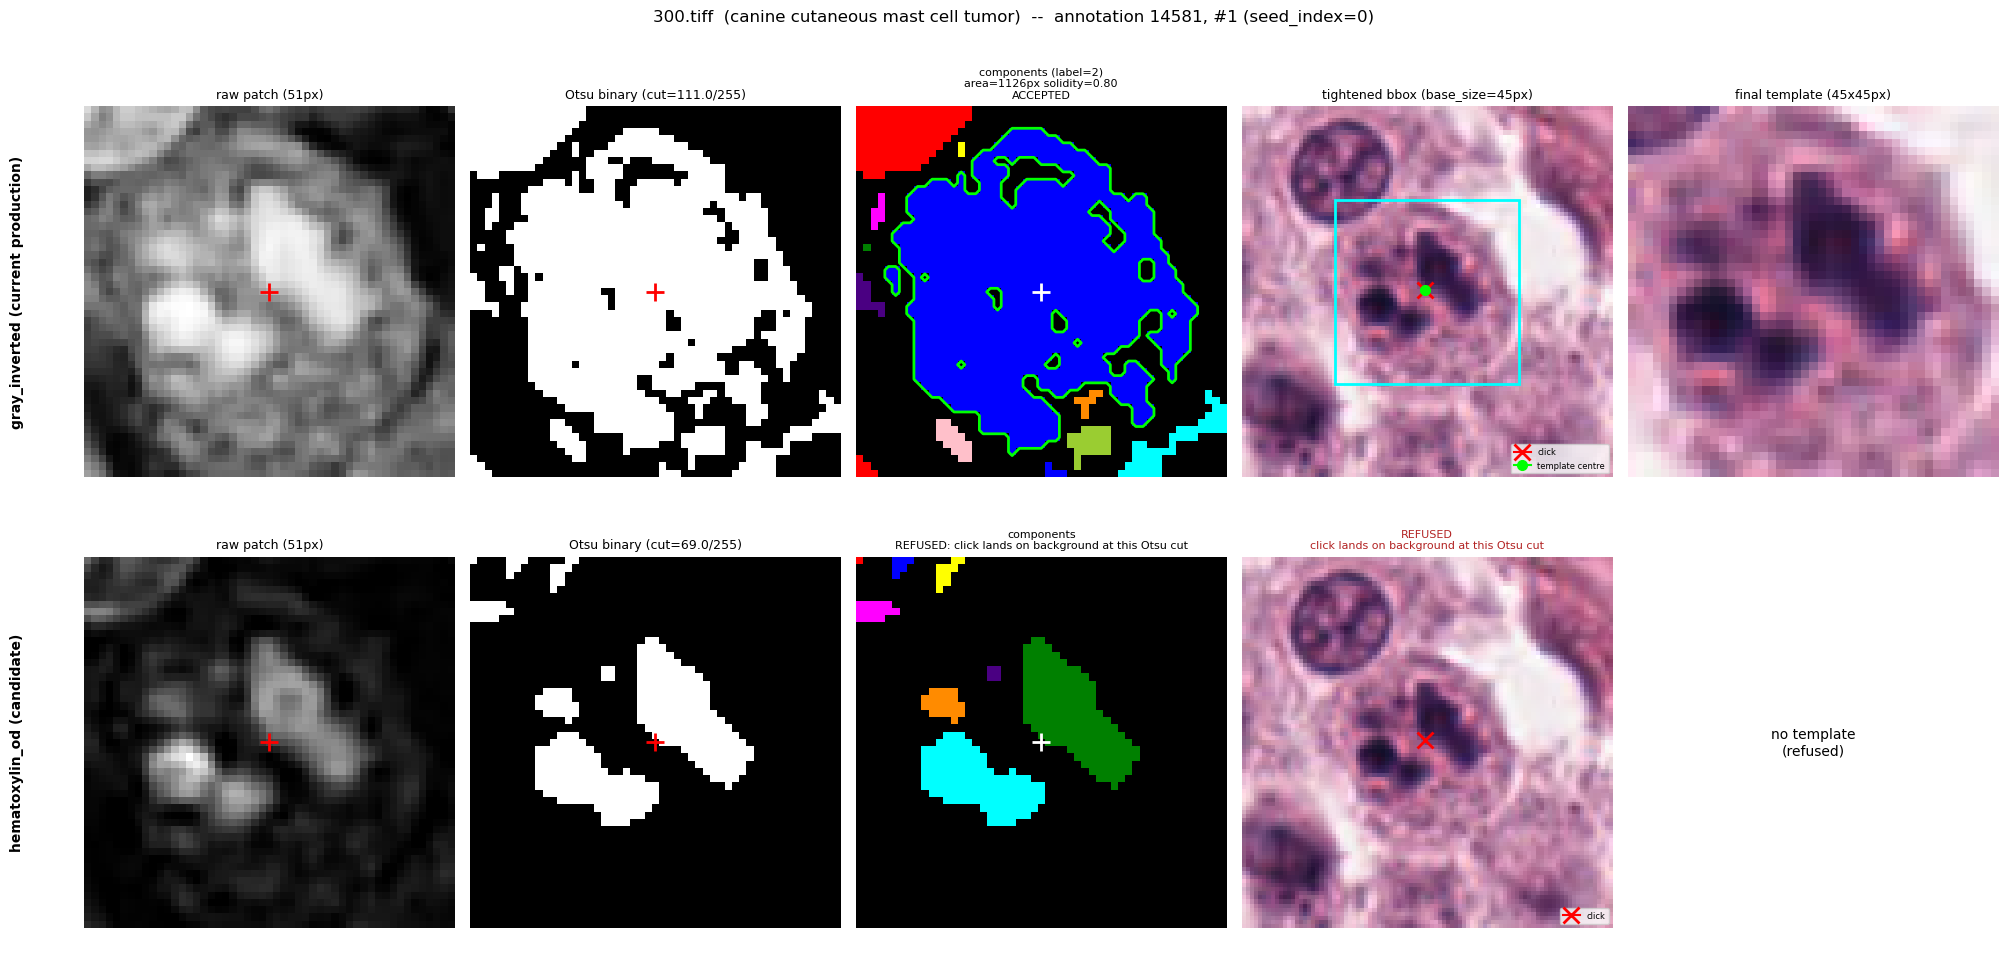

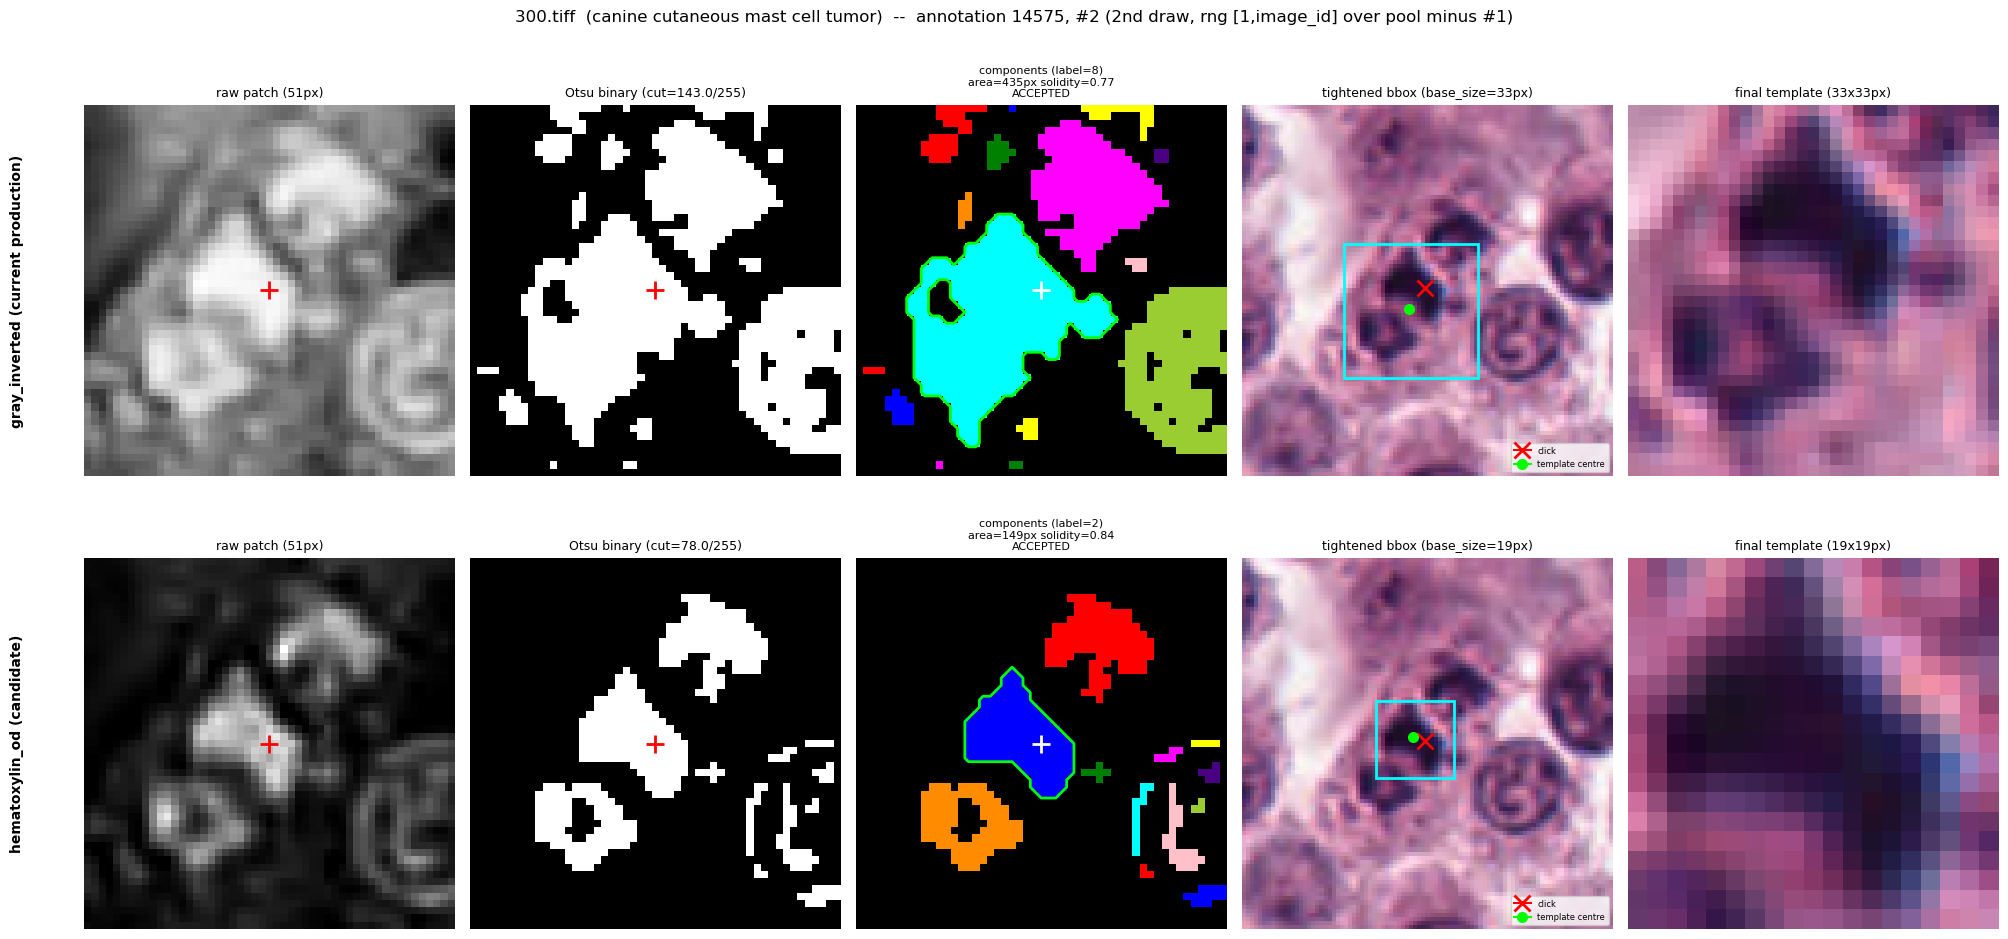

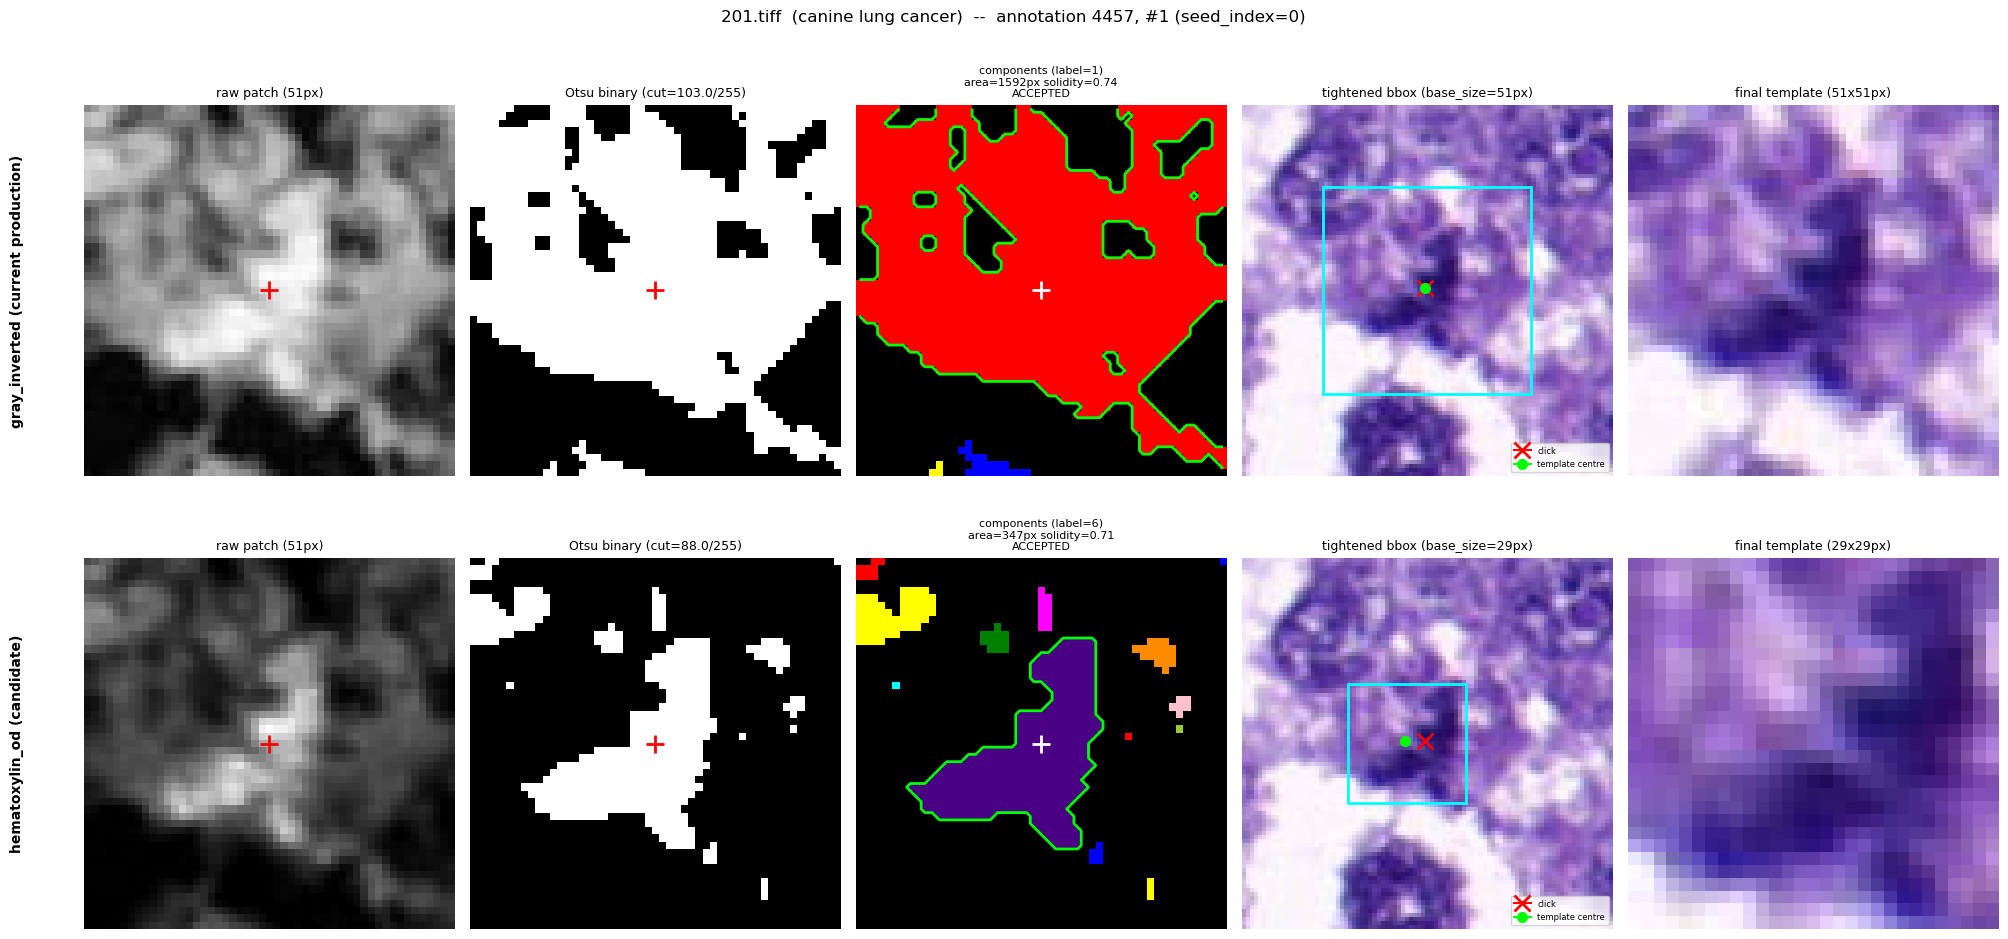

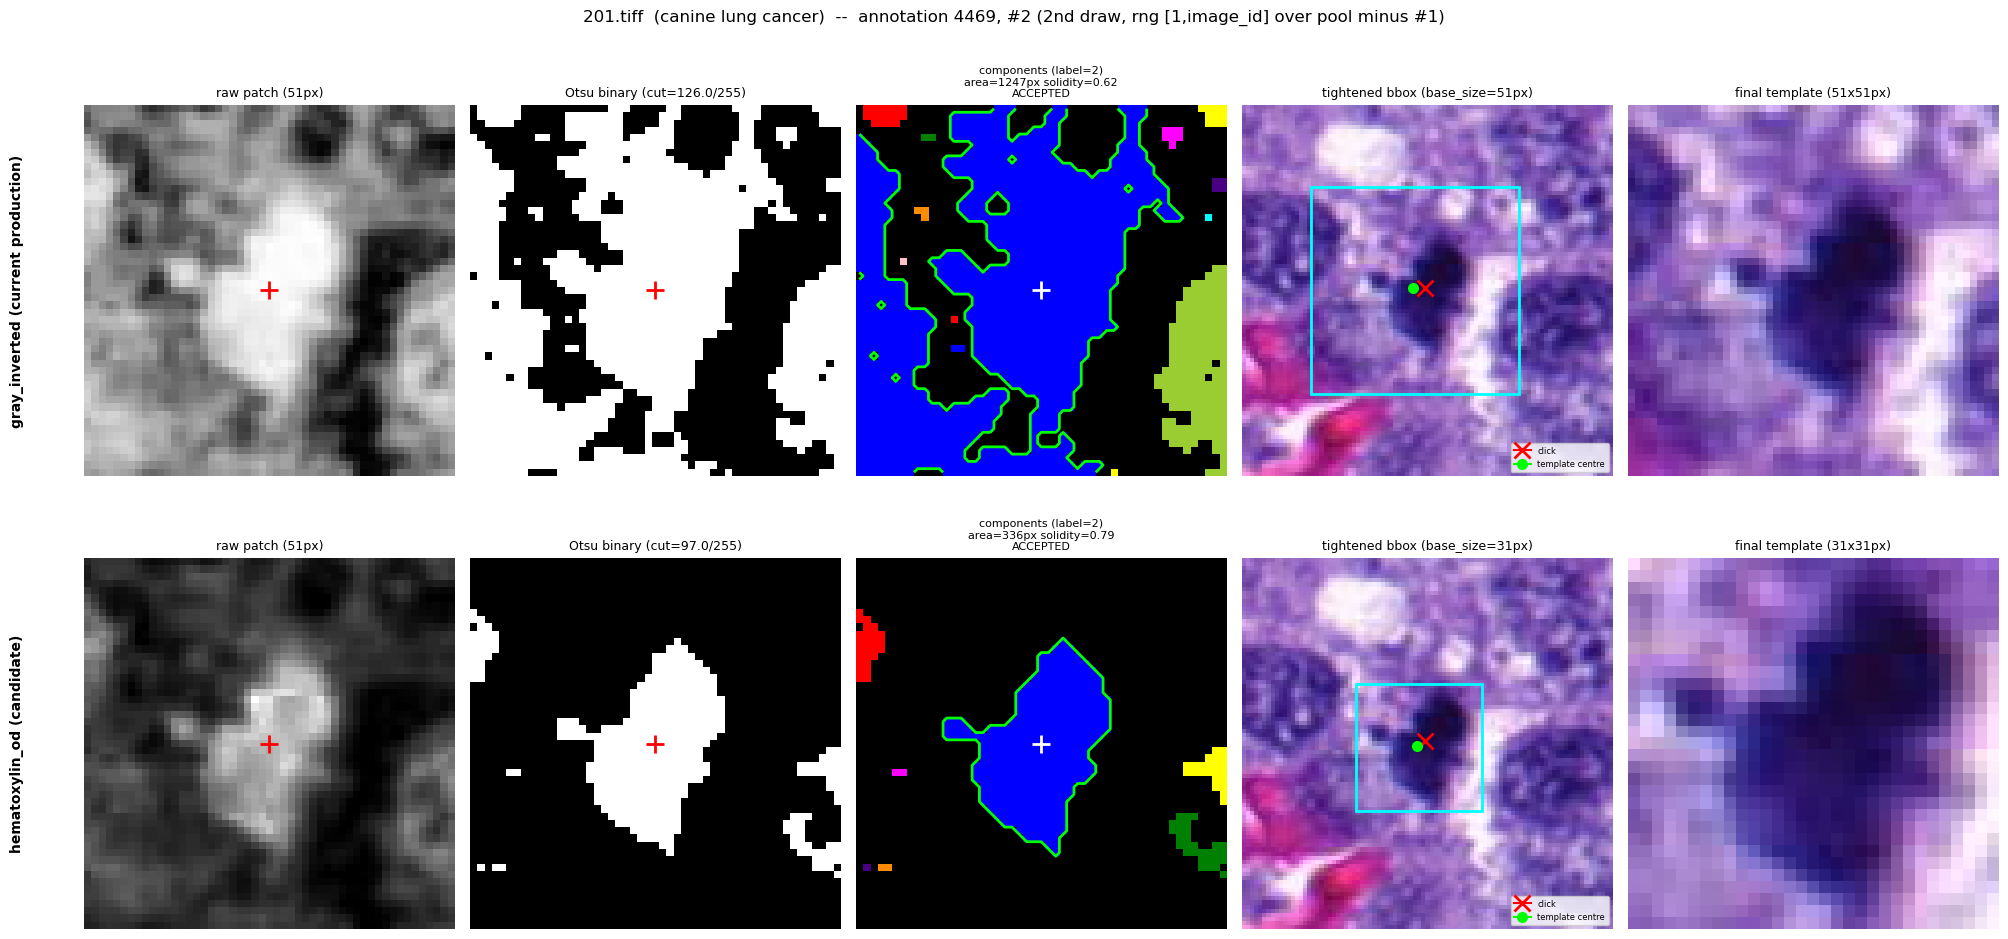

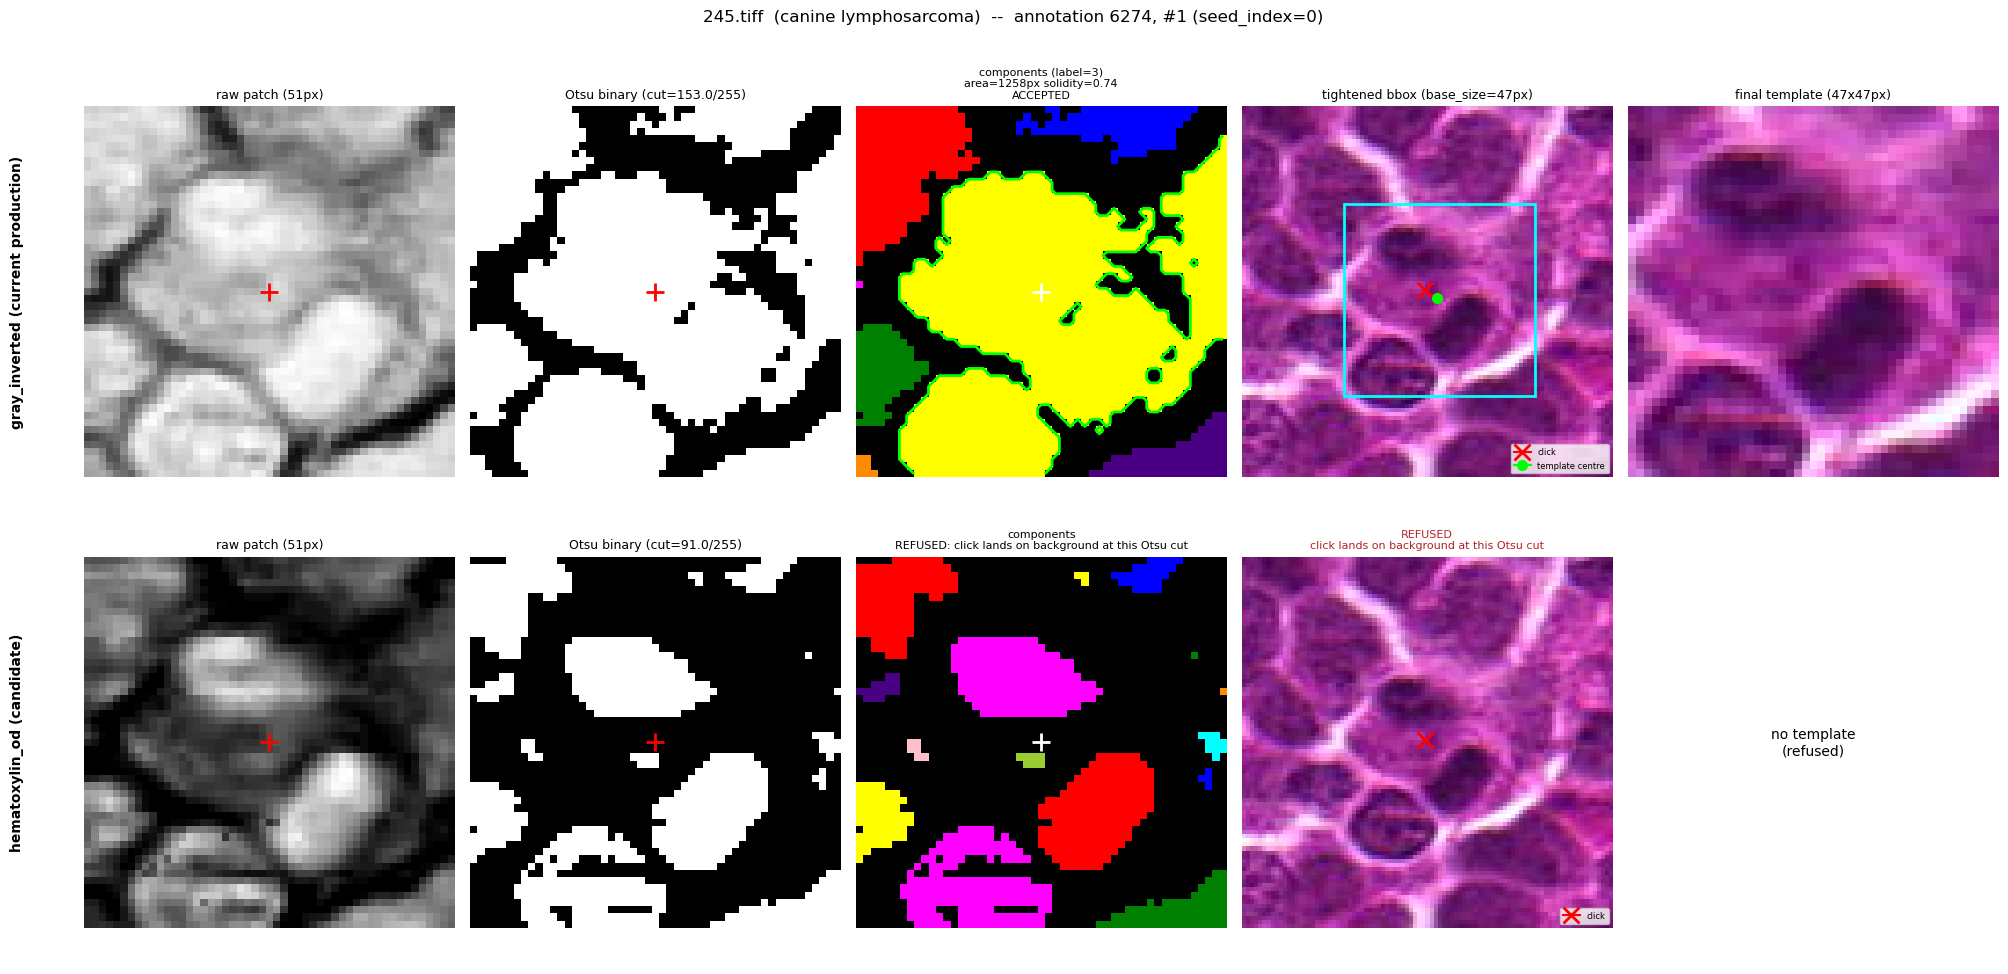

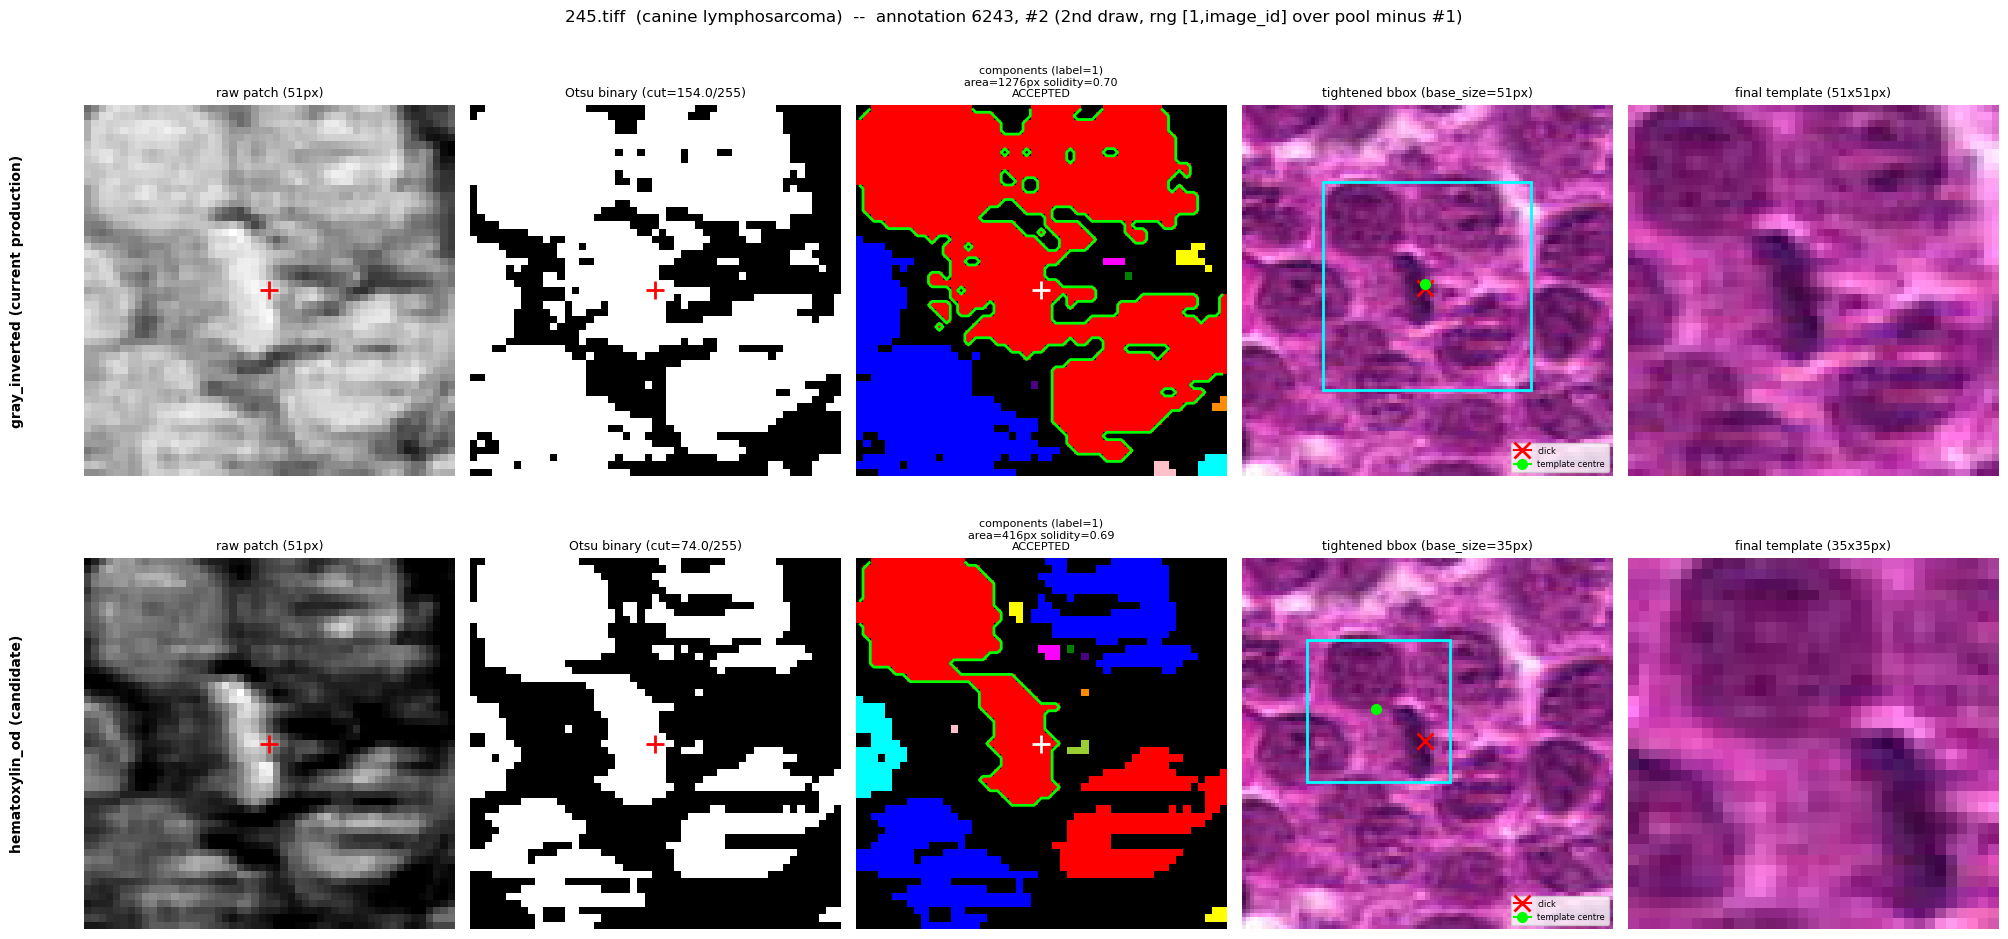

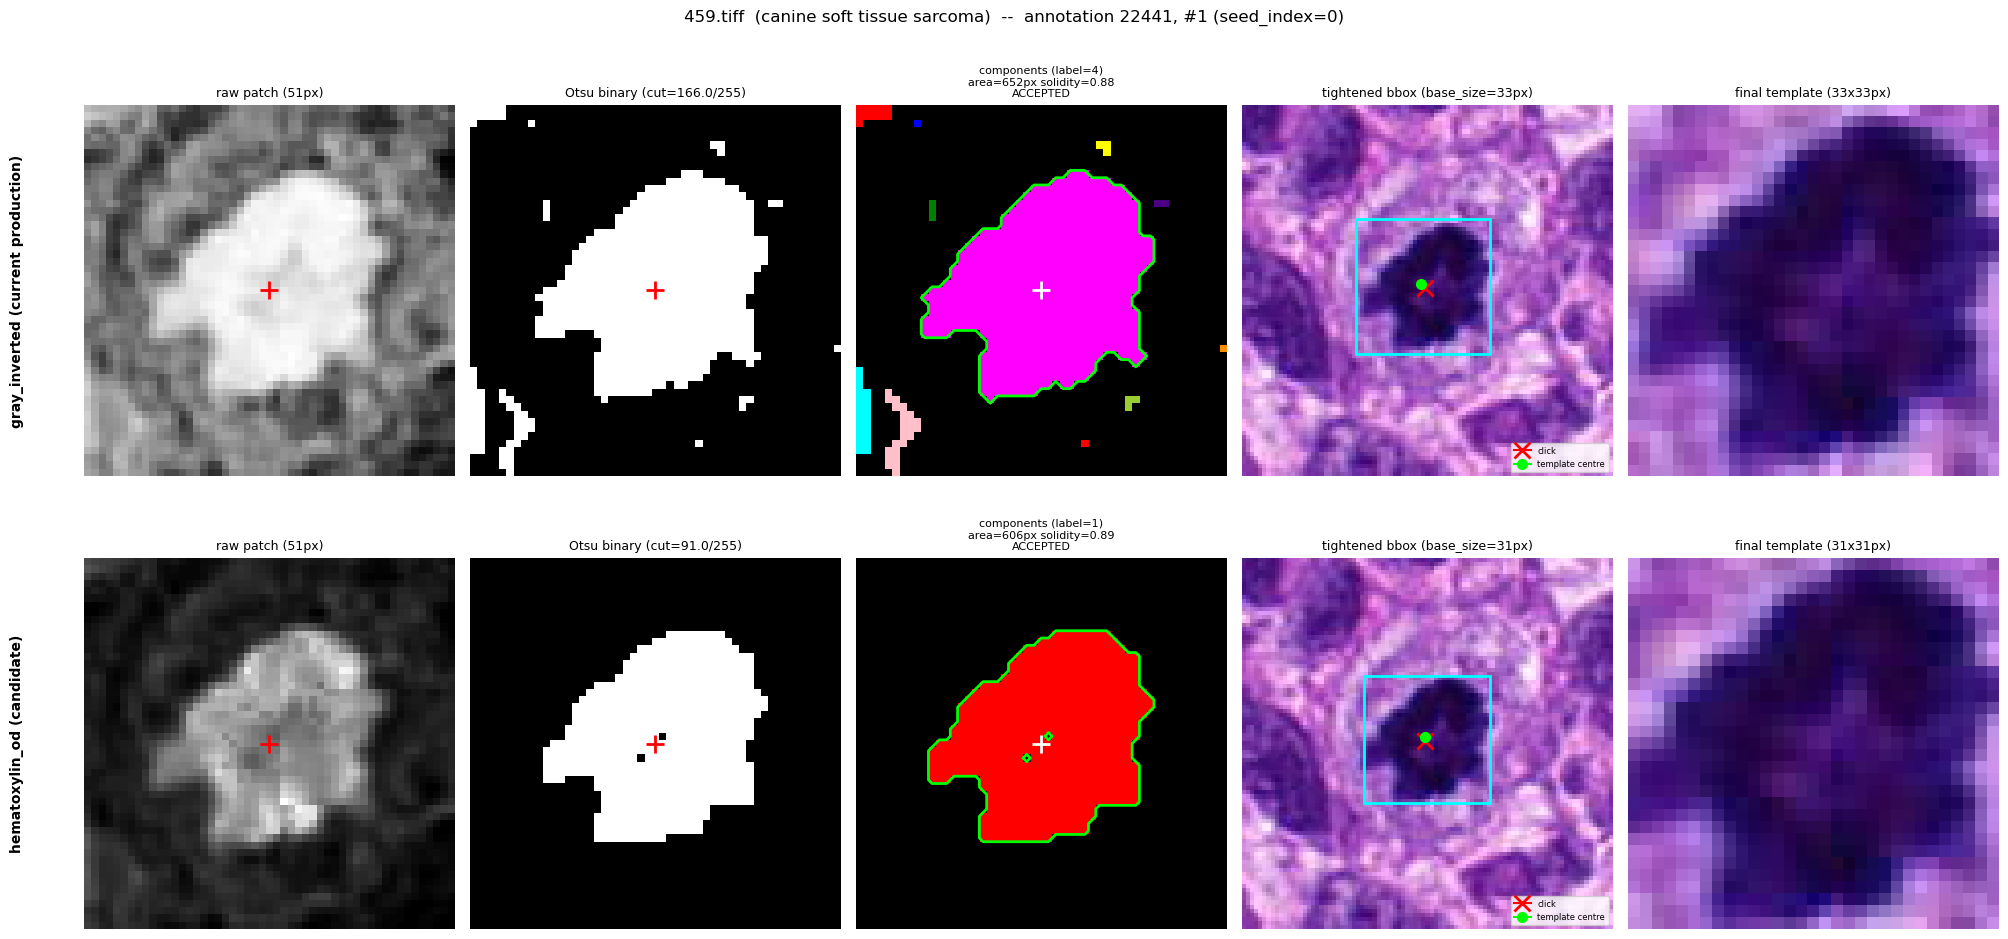

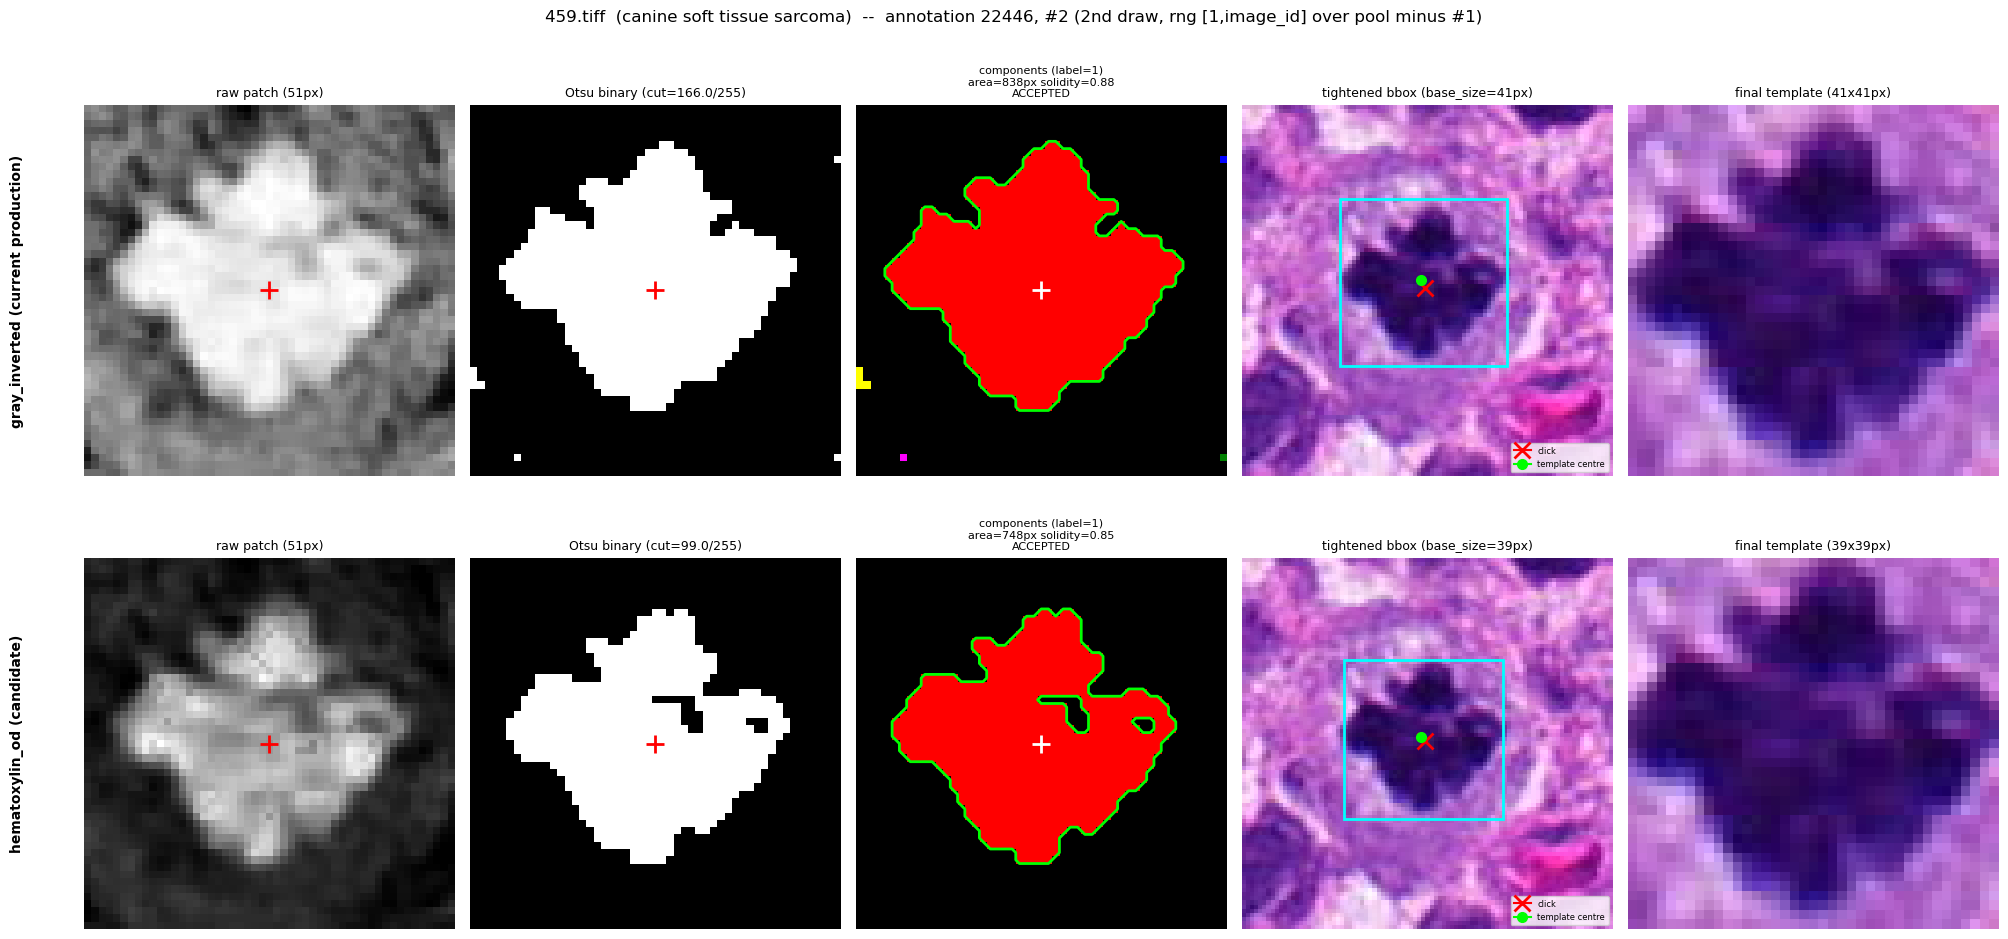

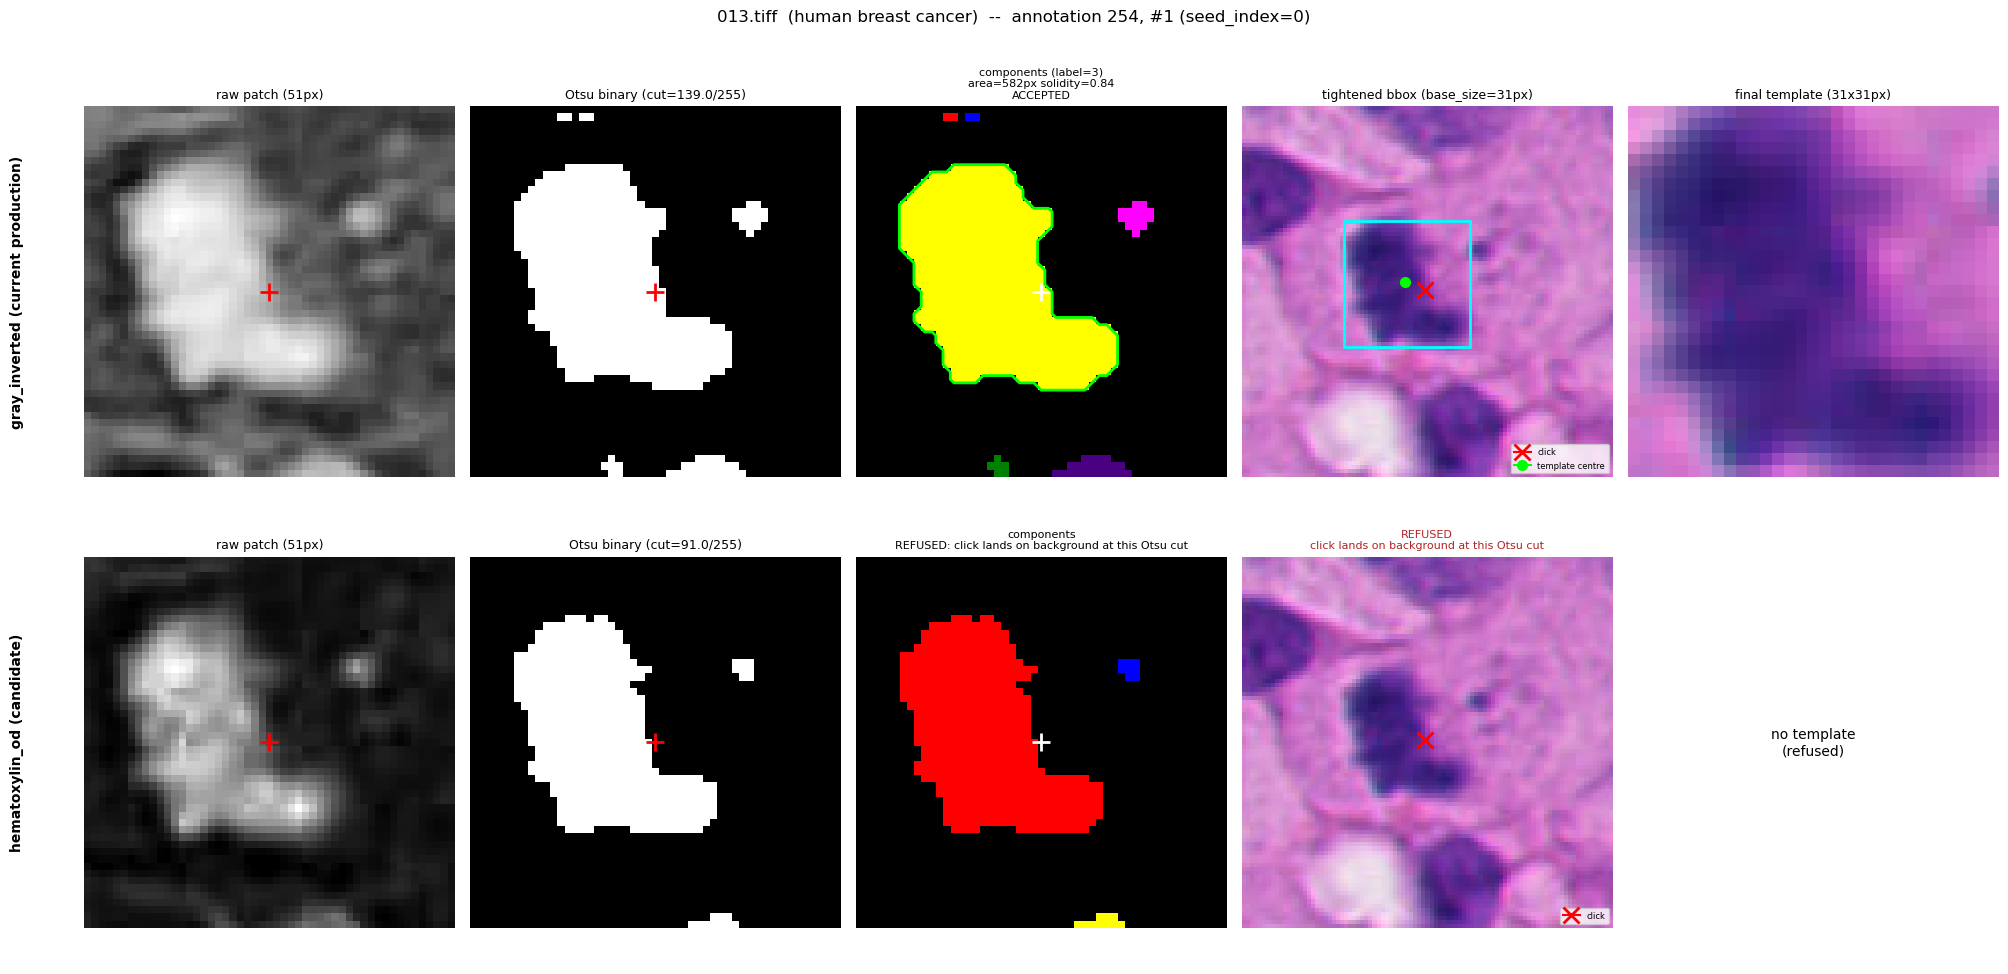

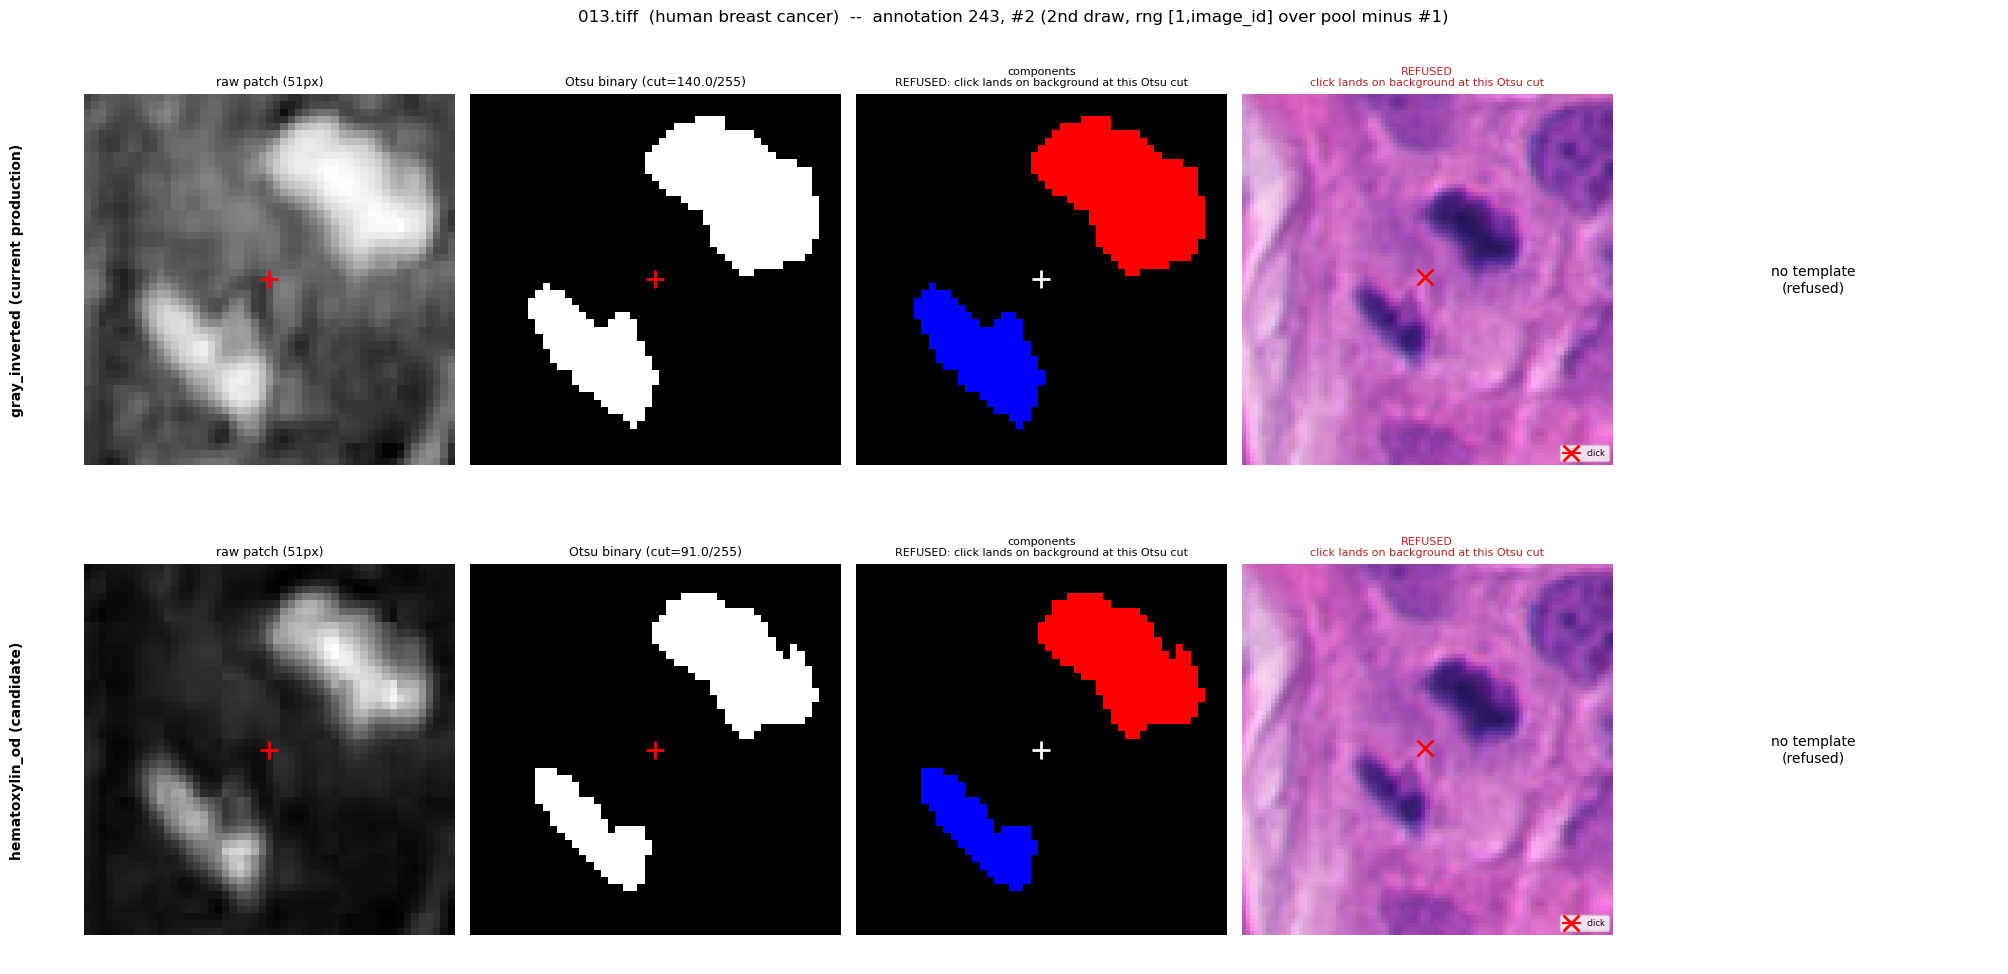

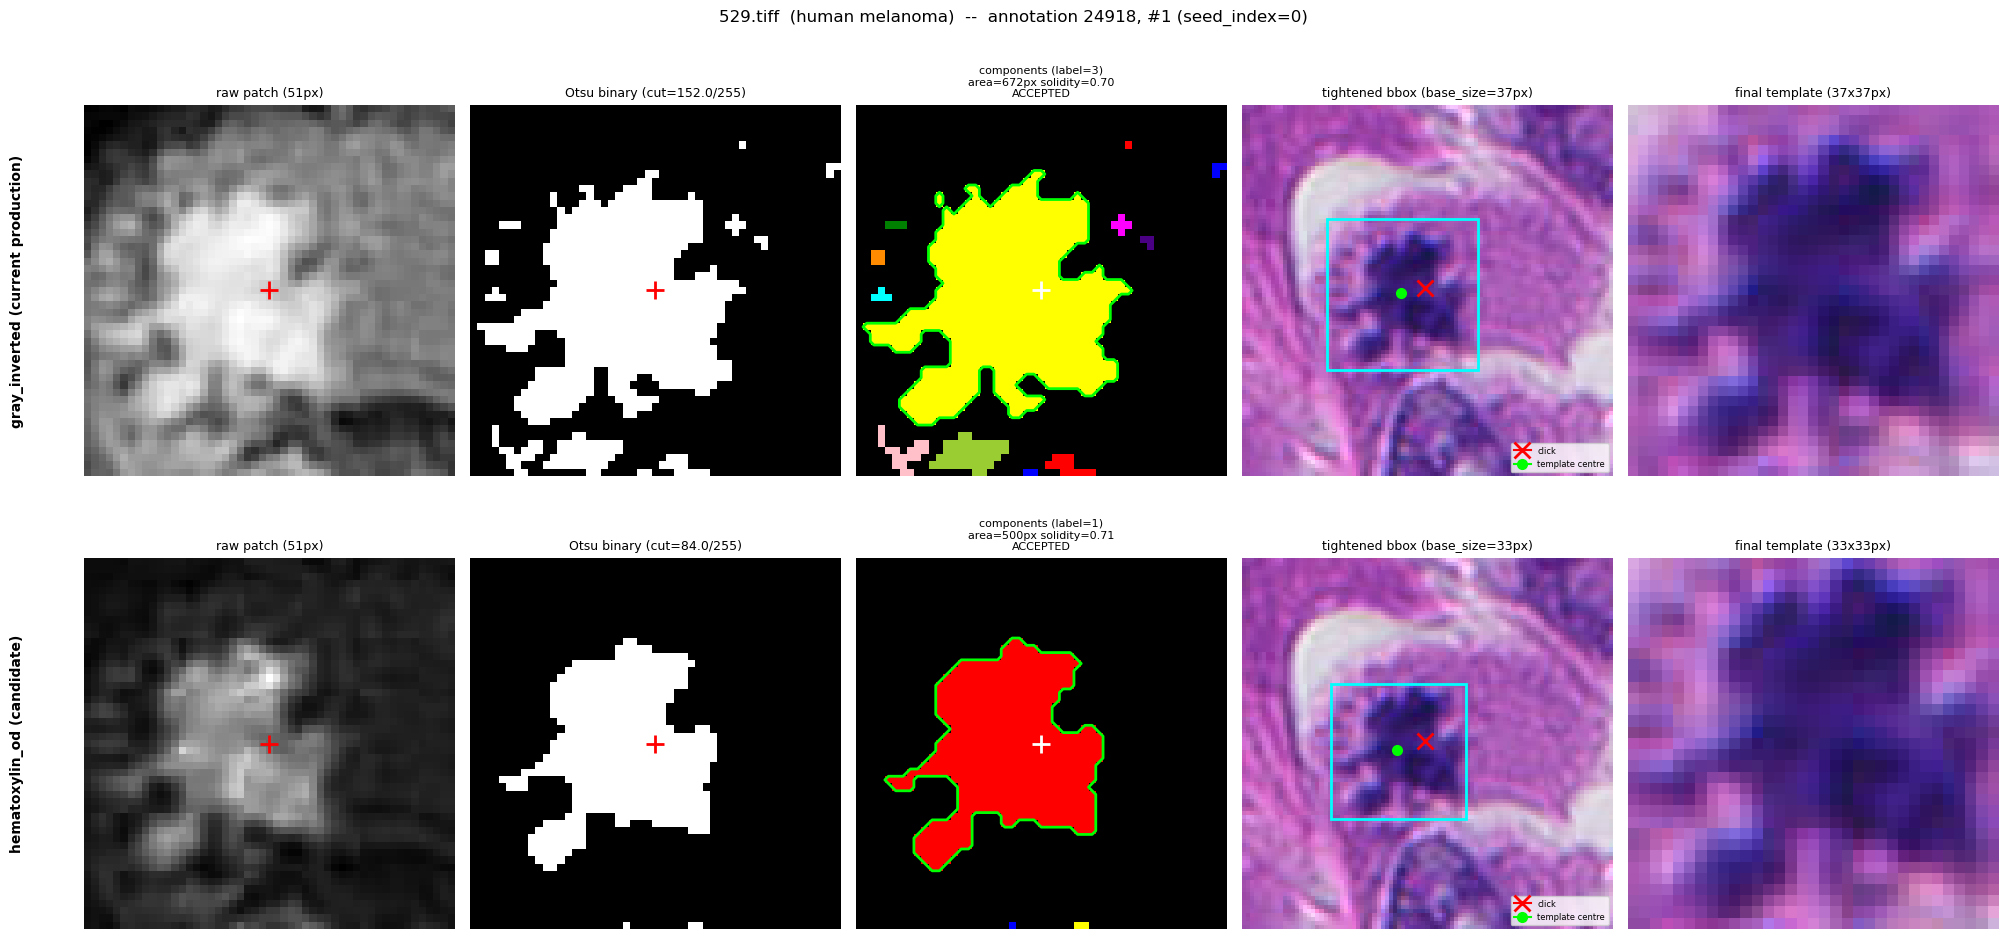

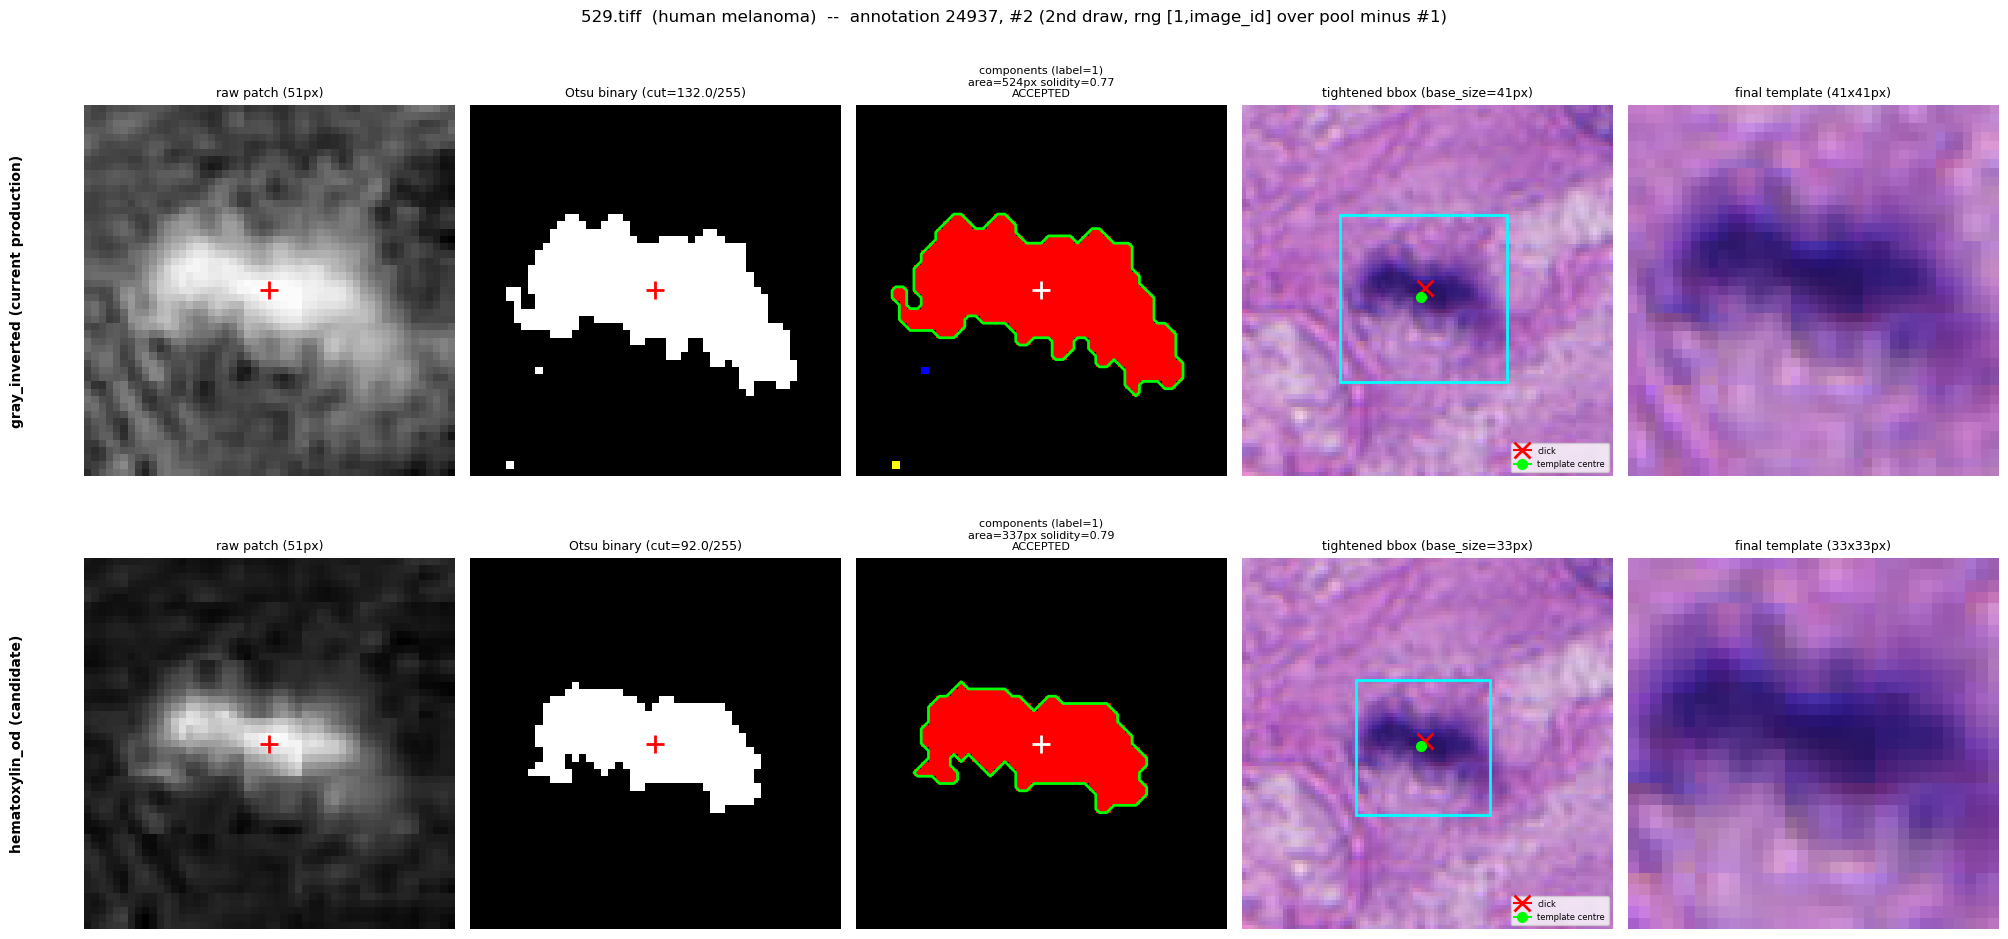

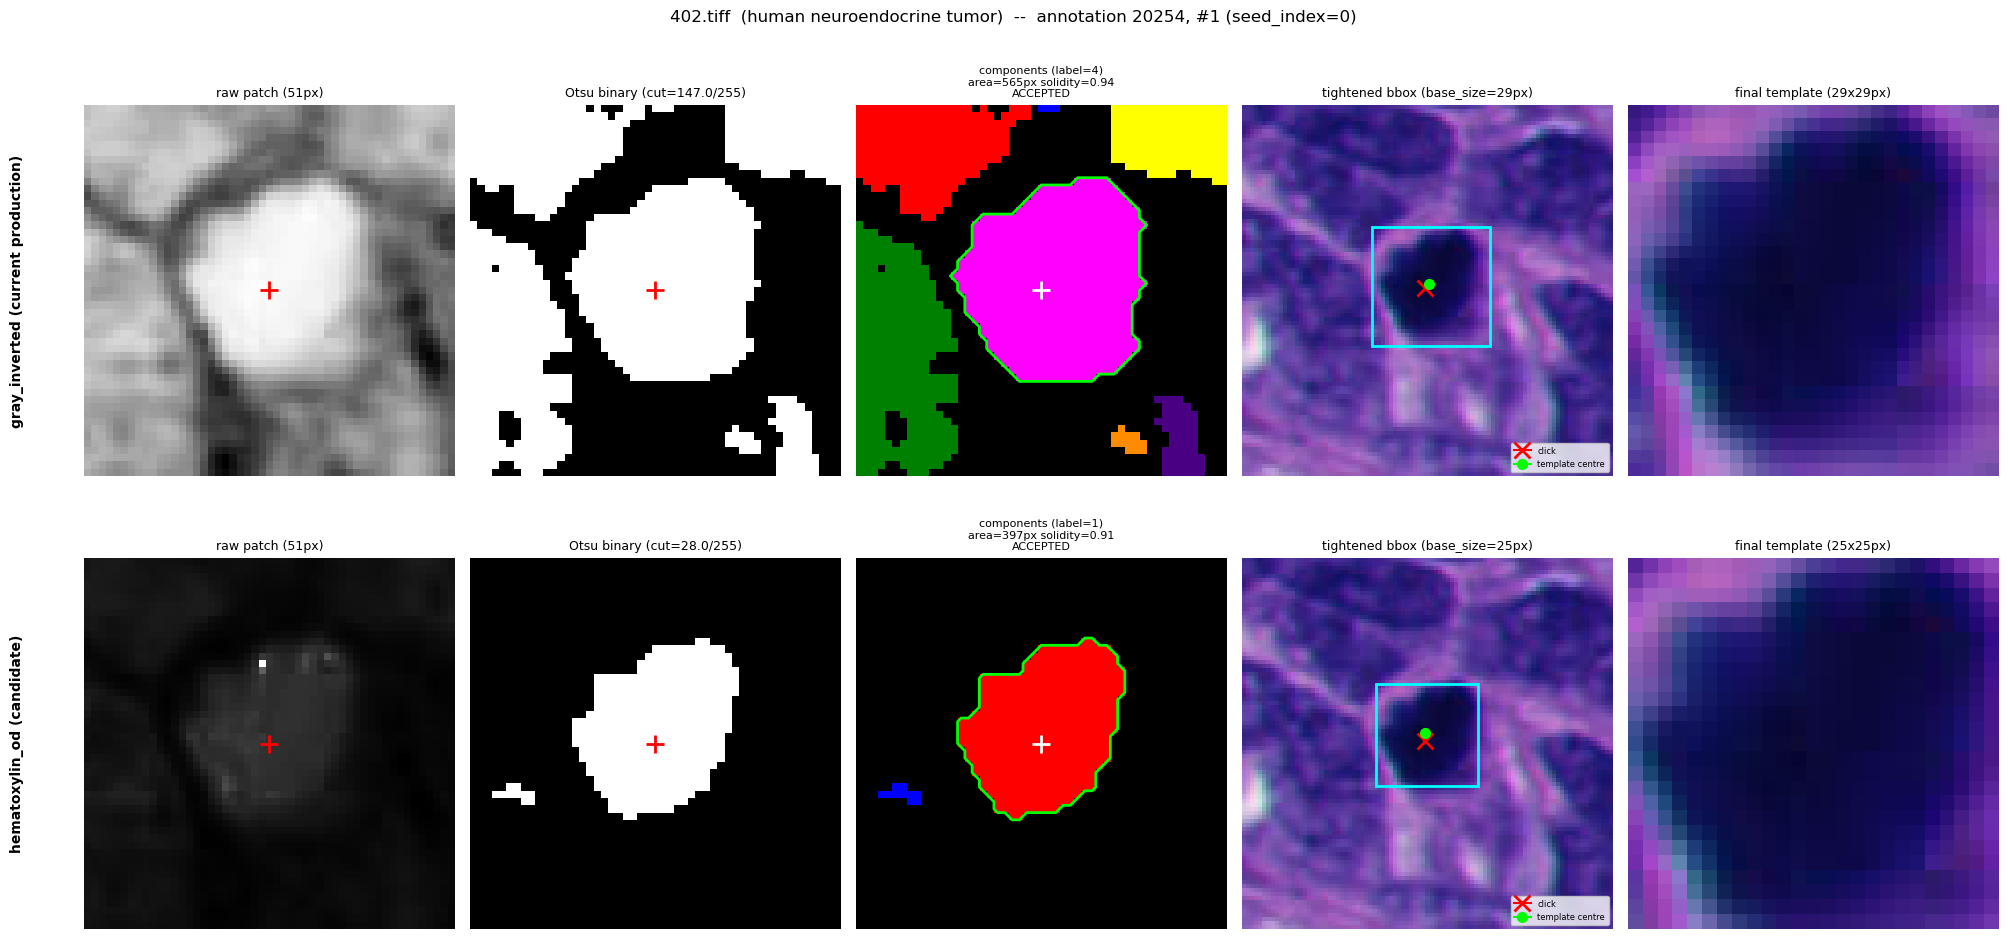

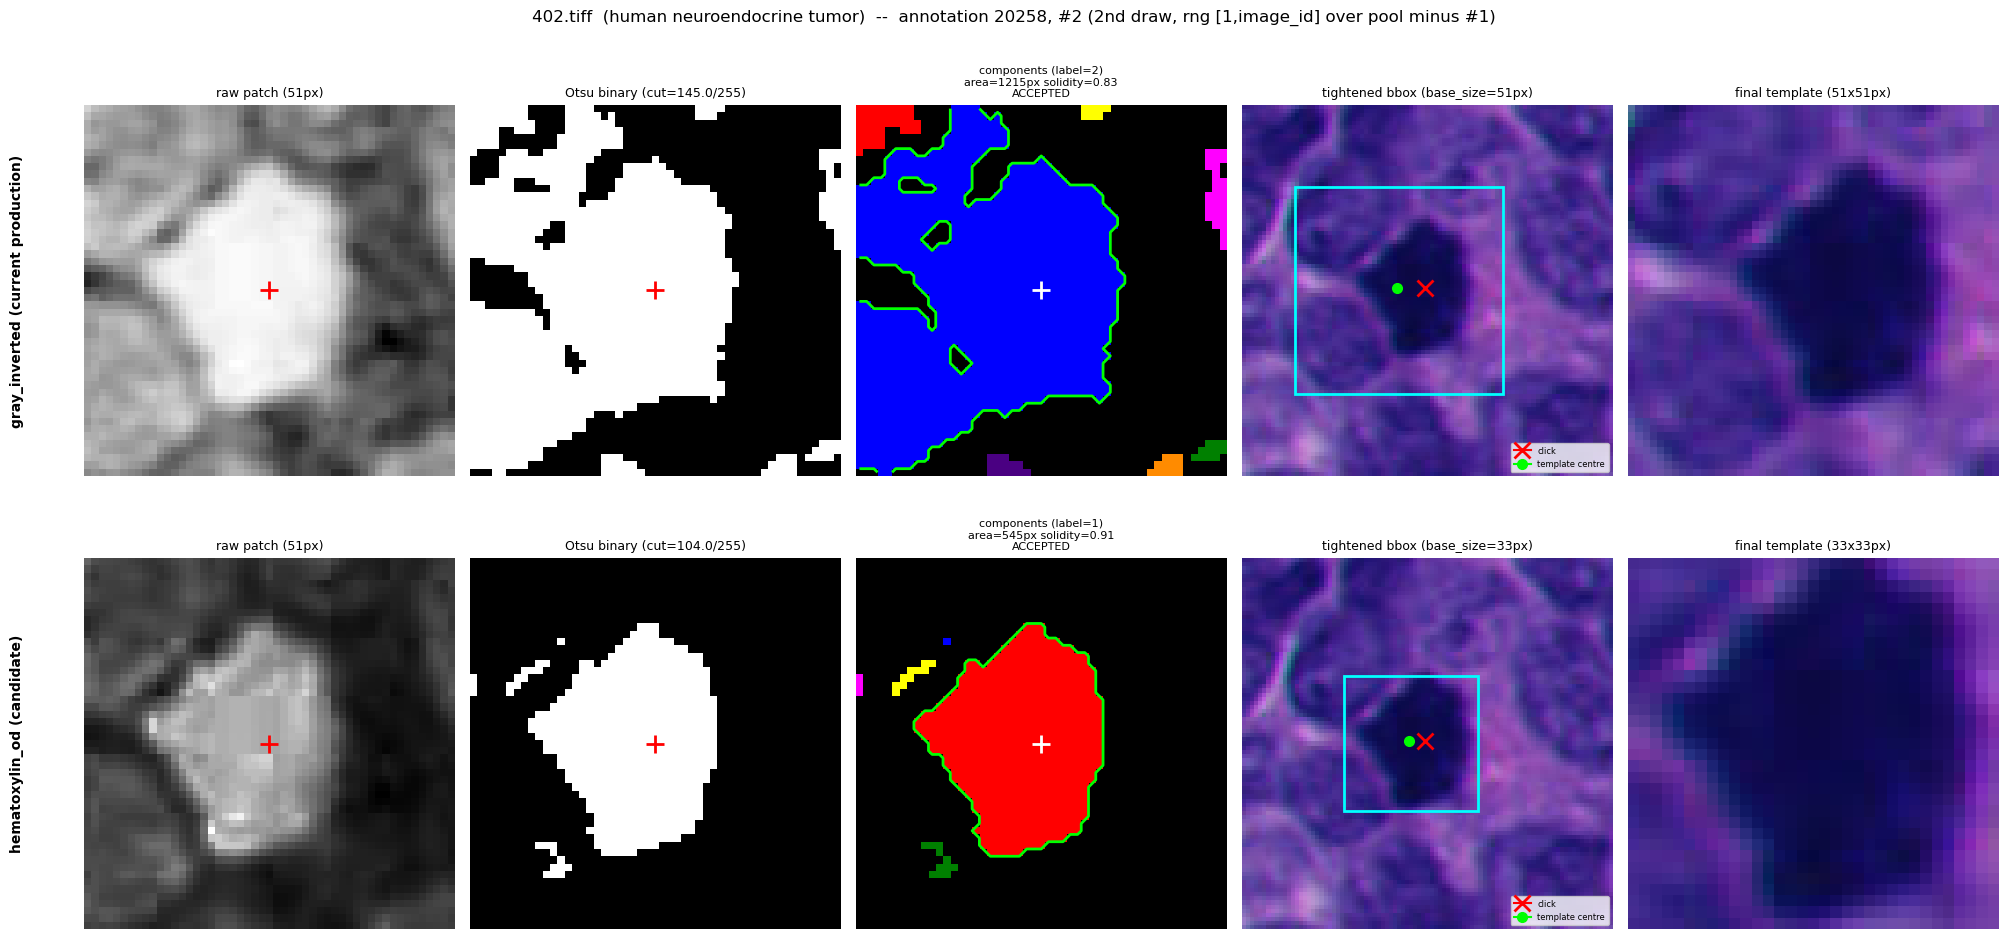

cross-check mismatches against ss.tighten_box_otsu / ss.tightened_template_box: 0


In [4]:
SUMMARY_ROWS = []
CROSS_CHECK_MISMATCHES = []

for ex in examples:
    fn, domain, which, row = ex['file_name'], ex['domain'], ex['which'], ex['row']
    ann_id, cx, cy = int(row['ann_id']), float(row['cx']), float(row['cy'])

    rgb = ds.load_roi(f'{IMAGES_DIR}/{fn}')

    fig, axes = plt.subplots(2, 5, figsize=(20, 9.6))
    for r, (ch_label, ch_key) in enumerate(CHANNELS.items()):
        chan = ch.to_channel(rgb, ch_key)
        res = explore_tightening(chan, cx, cy)

        # cross-check against the real functions -- not just a visual approximation of them
        official_bbox = ss.tighten_box_otsu(res['patch']) if res['patch'] is not None else None
        if (official_bbox is None) != (not res['accepted']):
            CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'accept/refuse disagrees'))
        elif res['accepted'] and official_bbox != res['bbox']:
            CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'bbox disagrees'))
        if res['patch'] is not None:
            official_tpl = ss.tightened_template_box(chan, cx, cy)
            if (official_tpl is None) != (not res['accepted']):
                CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'tightened_template_box accept/refuse disagrees'))
            elif res['accepted']:
                obs, ocx, ocy = official_tpl
                if obs != res['base_size'] or abs(ocx - res['center_xy'][0]) > 1e-9 or abs(ocy - res['center_xy'][1]) > 1e-9:
                    CROSS_CHECK_MISMATCHES.append((fn, ann_id, ch_key, 'tightened_template_box result disagrees'))

        plot_channel_row(axes[r], ch_label, res, rgb, cx, cy)
        SUMMARY_ROWS.append(dict(domain=domain, file_name=fn, which=which, ann_id=ann_id,
                                 channel=ch_key, accepted=res['accepted'],
                                 base_size=res['base_size'], reason=None if res['accepted'] else res['reason']))

    fig.suptitle(f'{fn}  ({domain})  --  annotation {ann_id}, {which}', fontsize=12, y=1.01)
    fig.tight_layout(h_pad=3.0)
    fig.savefig(f'tightening_{fn.replace(".tiff","")}_{ann_id}.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print(f'cross-check mismatches against ss.tighten_box_otsu / ss.tightened_template_box: '
     f'{len(CROSS_CHECK_MISMATCHES)}')
if CROSS_CHECK_MISMATCHES:
    print(CROSS_CHECK_MISMATCHES)
assert not CROSS_CHECK_MISMATCHES, 'the visualization diverged from the real tightening functions -- see above'

## Summary table

One row per (example, channel) -- 28 rows. `accepted=False` rows carry the refusal reason instead
of a `base_size`.

In [5]:
SUMMARY = pd.DataFrame(SUMMARY_ROWS)
SUMMARY.to_csv('tightening_process_summary.csv', index=False)
print(f"accepted: {int(SUMMARY['accepted'].sum())}/{len(SUMMARY)}")
print(SUMMARY.groupby('channel')['accepted'].agg(['sum', 'count']))
SUMMARY

accepted: 23/28
                sum  count
channel                   
gray_inverted    13     14
hematoxylin_od   10     14


,domain,file_name,which,ann_id,channel,accepted,base_size,reason
0,canine cutaneous mast cell tumor,300.tiff,#1 (seed_index=0),14581,gray_inverted,True,45.0,None
1,canine cutaneous mast cell tumor,300.tiff,#1 (seed_index=0),14581,hematoxylin_od,False,NaN,click lands on background at this Otsu cut
2,canine cutaneous mast cell tumor,300.tiff,"#2 (2nd draw, rng [1,image_id] over pool minus...",14575,gray_inverted,True,33.0,None
3,canine cutaneous mast cell tumor,300.tiff,"#2 (2nd draw, rng [1,image_id] over pool minus...",14575,hematoxylin_od,True,19.0,None
4,canine lung cancer,201.tiff,#1 (seed_index=0),4457,gray_inverted,True,51.0,None
5,canine lung cancer,201.tiff,#1 (seed_index=0),4457,hematoxylin_od,True,29.0,None
6,canine lung cancer,201.tiff,"#2 (2nd draw, rng [1,image_id] over pool minus...",4469,gray_inverted,True,51.0,None
7,canine lung cancer,201.tiff,"#2 (2nd draw, rng [1,image_id] over pool minus...",4469,hematoxylin_od,True,31.0,None
8,canine lymphosarcoma,245.tiff,#1 (seed_index=0),6274,gray_inverted,True,47.0,None
9,canine lymphosarcoma,245.tiff,#1 (seed_index=0),6274,hematoxylin_od,False,NaN,click lands on background at this Otsu cut


## Closing note

**Two distinct effects are visible across these 14 examples, not one.**

**1. `hematoxylin_od` refuses outright more often.** `gray_inverted` accepted 13/14; `hematoxylin_od`
accepted only 10/14. On three of the four hematoxylin refusals (`300.tiff` ann 14581,
`245.tiff` ann 6274, `013.tiff` ann 254), `gray_inverted` found a valid component at that exact
click and `hematoxylin_od` classified the same pixel as background at its Otsu cut -- visible in
panel 2/3 of those figures as a click marker sitting outside every colored blob. This isn't a
template-size effect, it's a different accept/refuse decision at the same pixel: in production
(where a refusal triggers a redraw, not a hard failure) this means more retries, and in this
notebook's un-retried view, it means some clicks simply have no hematoxylin-based template at all.

**2. Where both channels accept, `hematoxylin_od` gives a smaller box -- every time.** All 10
examples both channels accepted: **correction** (audit Finding T2-1) -- an earlier version of
this cell named "`300.tiff`#2 45->19px" as the extreme; `45` was actually `300.tiff`**#1**'s
`gray_inverted` size, and that annotation's `hematoxylin_od` run was *refused*, so it isn't a
pair at all. `300.tiff`#2 is really `33->19` (-42%). The true extreme is `201.tiff`#1,
`51->29` (-22px, -43%); among the six uncensored pairs, `300.tiff`#2 is the largest (though three of the censored pairs above have larger absolute px shrinks). `459.tiff`#1/#2 barely move
(33->31, 41->39). Visually (panel 3 of each figure), the `gray_inverted` component tends to
trace the fuller, softer nuclear outline, while the `hematoxylin_od` component is confined to the
densest, most heavily-stained chromatin -- a visibly different Otsu cut on the same tissue, not
just a differently-scaled one. **Caveat** (audit Finding T2-2): on 4 of the 10 pairs (`201`#1,
`201`#2, `245`#2, `402`#2) the `gray_inverted` component's bounding box spans the *entire* 51px
Otsu window, so its `base_size=51` is right-censored -- a lower bound on the true size, not a
measurement of one nuclear outline. On those four, `gray_inverted`'s accepted component covers
47-61% of the window and reads (checked against the renders) as a merged multi-nucleus/stroma
blob rather than the clicked nucleus alone -- and those four are exactly the four largest
shrinks in the run. The direction still holds on all 10 pairs, including the six uncensored
ones (-5% to -42%); what changes is that the *largest* quoted numbers are lower bounds on the
gray side, not a same-object size comparison. This is the same pattern
`production_seed_precision_at_k_chromatin_hem_bbox.ipynb` measured at full scale (13/14 ROIs
shrink, median -13.3% per ROI over 14 production seeds) -- the two runs agree to the decimal
on all four pairs they measure on the same click (201/4457, 459/22441, 529/24918, 402/20254:
-43.1%, -6.1%, -10.8%, -13.8% in both), so this is not a disagreement. The medians differ only
because this notebook's -25.4% is taken over all 10 both-accepted pairs, including the `#2`
draws, which appear in no production run -- over the `#1` draws alone the median here is
-12.3%, close to the sibling's.

**Correction.** An independent audit of that notebook
(`Research Logs/2026-09-16-hembbox-precision-at-k-audit.md`, Finding T1-4) found the mechanism
originally proposed here -- that this size shrink is *why* `tm_score` precision fell -- does not
hold up. Correlating each ROI's template-size change against its precision change finds no
relationship (Spearman, computed exactly from integer true-positive counts to avoid float noise:
every arm/budget non-significant, p>=0.16, and on `tm_score` the ROIs that shrank the *most* did
not have the worse precision deltas -- see that notebook's Statistical context section). The size
difference shown here is real and consistently measured; what it causes downstream is not
established.

Together: switching the bbox-tightening channel from `gray_inverted` to `hematoxylin_od` is not a
free, behaviourally-neutral simplification -- it changes both *which* clicks pass the gate and
*how large* the resulting template is when they do, and both effects point the same direction
(smaller, more selective) rather than offsetting each other.